# Lab: Exploratory Decision Trees — Breast Cancer Wisconsin Dataset (Student Worksheet)

**Objective:** Build intuition for how a Decision Tree Classifier actually behaves —
not just how to call `.fit()`. You will explore split criteria (Gini vs Entropy),
tree depth, and other hyperparameters to find the configuration that generalizes best.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features,
binary target (malignant / benign), built into `sklearn.datasets`.

**How this notebook works:** Sections 1-3 (Setup, EDA, Baseline) are fully worked for
you — run them as-is, they set up everything you need. From Section 4 onward, cells
marked **`# TODO`** contain instructions but *no solution code* — you write that part
yourself. Later cells often depend on variable names introduced in an earlier TODO
(the instructions tell you what name to use), so work through the sections in order.

---
## 1. Setup & Dataset

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
np.random.seed(42)

RANDOM_STATE = 42

In [45]:
%matplotlib inline

In [46]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("Classes:", dict(zip(data.target_names, [0, 1])))
print(y.value_counts())
X.head()

Shape: (569, 30)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## 2. Quick EDA

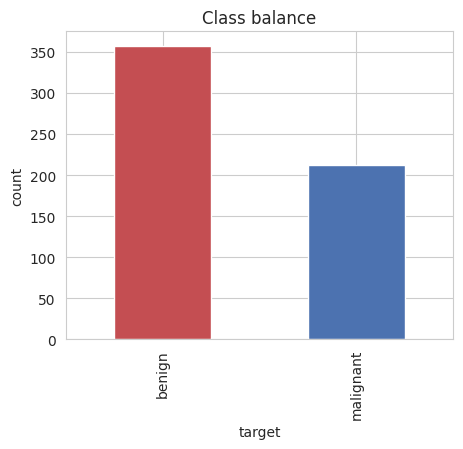

target
1    0.627
0    0.373
Name: proportion, dtype: float64


In [47]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: 'malignant', 1: 'benign'}).plot(kind='bar', ax=ax, color=['#c44e52', '#4c72b0'])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

print(y.value_counts(normalize=True).round(3))

**TODO (reflection):** Is this dataset balanced or imbalanced? Keep this in mind —
you'll come back to it in Section 8 when judging whether a model's accuracy number
alone tells the full story.

*Your answer:* — *(replace this line)*

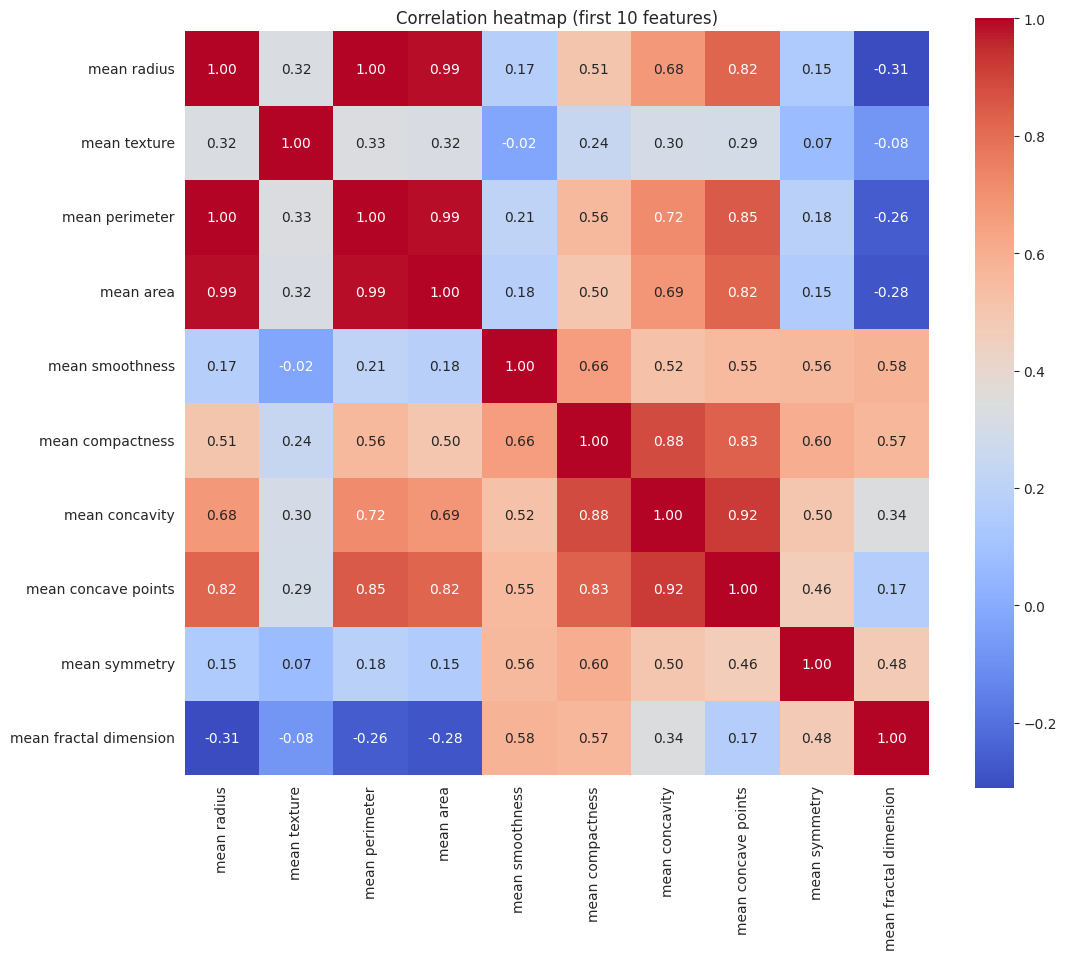

In [48]:
plt.figure(figsize=(12, 10))
corr = X.iloc[:, :10]  # first 10 features, full 30x30 is unreadable
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (first 10 features)")
plt.show()

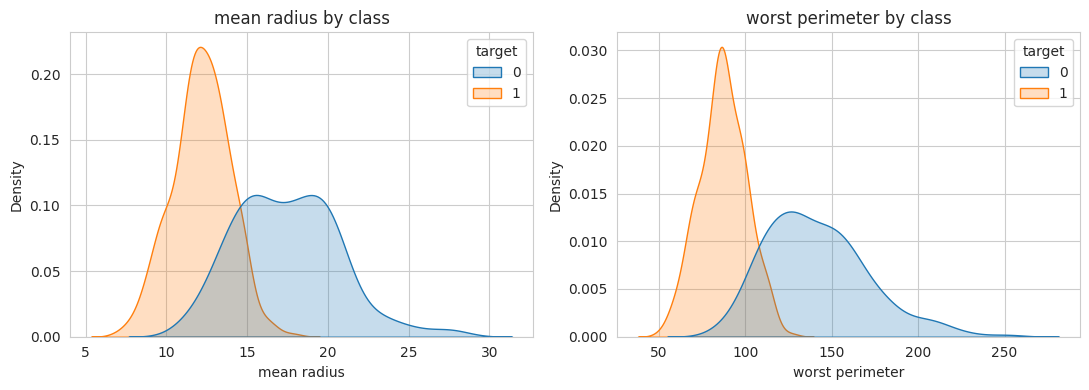

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['mean radius', 'worst perimeter']):
    sns.kdeplot(data=X.assign(target=y), x=feat, hue='target', fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{feat} by class")
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Train test split first, then fit a plain, default-parameter `DecisionTreeClassifier`.
Everything after this cell is measured against this baseline.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


In [51]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Baseline tree depth:", baseline_model.get_depth(), " | leaves:", baseline_model.get_n_leaves())
print()
print(classification_report(y_test, baseline_pred, target_names=data.target_names))

Baseline accuracy: 0.9123
Baseline tree depth: 7  | leaves: 19

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



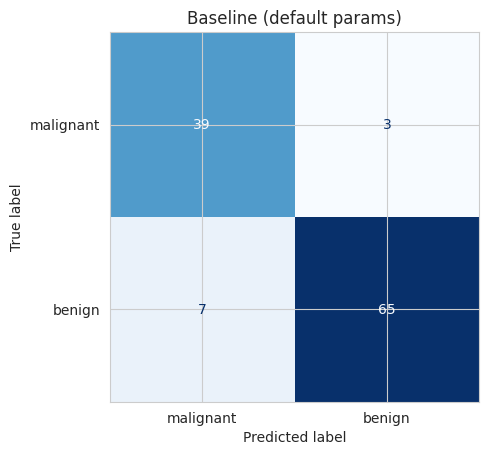

array([[39,  3],
       [ 7, 65]])

In [52]:
def plot_confusion(model, X_te, y_te, title):
    """Reusable confusion matrix plotter — you'll call this throughout the rest of the lab."""
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()
    return cm

plot_confusion(baseline_model, X_test, y_test, "Baseline (default params)")

---
## 4. Gini vs Entropy

Same tree, same split, only the impurity measure changes.

In [53]:
# TODO: train one DecisionTreeClassifier per criterion in ['gini', 'entropy']
#       (same random_state=RANDOM_STATE, no other params changed).
#       For each, compute test-set accuracy and store it in a dict:
#           criterion_results = {'gini': <acc>, 'entropy': <acc>}
#       Print each criterion name, its accuracy, and the resulting tree depth
#       (hint: model.get_depth()).

criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc
    print(f"Criterion: {criterion}, Accuracy: {round(acc, 4)}, Depth: {model.get_depth()}")


Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


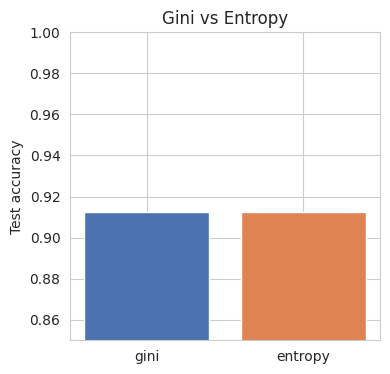

In [54]:
criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc
    print(f"Criterion: {criterion}, Accuracy: {round(acc, 4)}, Depth: {model.get_depth()}")

plt.figure(figsize=(4, 4))
plt.bar(criterion_results.keys(), criterion_results.values(), color=['#4c72b0', '#dd8452'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test accuracy")
plt.title("Gini vs Entropy")
plt.show()

**TODO (reflection):** Gini and Entropy are both impurity measures but computed
differently (Gini: `1 - sum(p_i^2)`, Entropy: `-sum(p_i * log2(p_i))`). Did they produce
the same accuracy here? If so, does that mean they always pick the same splits — or just
that this dataset doesn't stress the difference? Write 2-3 sentences.

*Your answer:* — *(replace this line)*

---
## 5. Depth Exploration — the core overfitting curve

Sweep `max_depth` from 1 to 20 and track **train** and **test** accuracy separately.
This is the single most important plot in the lab.

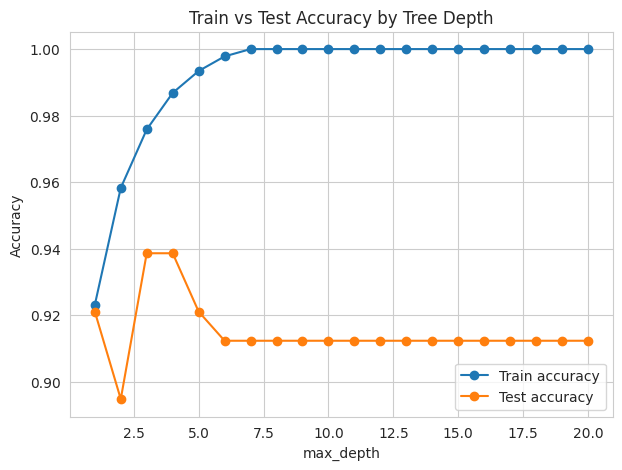

In [55]:
# TODO: for max_depth in range(1, 21):
#         - train a DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
#         - record TRAIN accuracy and TEST accuracy separately, in two lists
#       Use these exact names so later cells can find them:
#           depths = range(1, 21)
#           train_accs = [...]
#           test_accs  = [...]
#       Then plot both curves on the same figure (max_depth on x-axis, accuracy
#       on y-axis), with a legend distinguishing train vs test.

depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(depths, train_accs, marker='o', label='Train accuracy')
plt.plot(depths, test_accs, marker='o', label='Test accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.show()


In [56]:
# TODO: using your test_accs list from above, find the max_depth value that
#       achieves the highest test accuracy. Store it as `best_depth_by_test`
#       (later cells use this exact name) and print it, along with the train
#       accuracy at that same depth.

best_depth_by_test = list(depths)[int(np.argmax(test_accs))]
print("Best max_depth by test accuracy:", best_depth_by_test)
print("Train accuracy at that depth:", round(train_accs[list(depths).index(best_depth_by_test)], 4))
print("Test accuracy at that depth:", round(max(test_accs), 4))


Best max_depth by test accuracy: 3
Train accuracy at that depth: 0.9758
Test accuracy at that depth: 0.9386


---
## 6. Accuracy vs Depth, split by Criterion

Same sweep, but gini and entropy plotted separately — does the optimal depth shift?

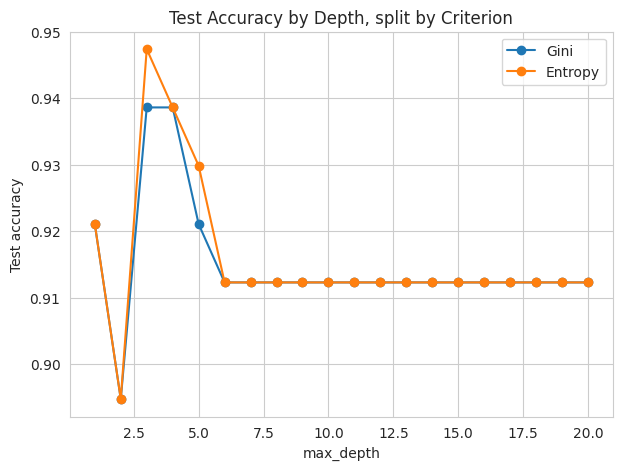

Best criterion: entropy  Best depth: 3  Accuracy: 0.9474


In [57]:
# TODO: repeat the depth sweep from Section 5, but this time for BOTH
#       criteria ('gini' and 'entropy'), tracking TEST accuracy only.
#       Store results as a nested structure, using this exact name:
#           depth_criterion_results = {'gini': [...], 'entropy': [...]}
#       (one accuracy value per depth in `depths`, same order)
#       Plot both lines on one figure, labeled by criterion.

depth_criterion_results = {'gini': [], 'entropy': []}

for criterion in ['gini', 'entropy']:
    for d in depths:
        model = DecisionTreeClassifier(criterion=criterion, max_depth=d, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        depth_criterion_results[criterion].append(acc)

plt.figure(figsize=(7, 5))
plt.plot(depths, depth_criterion_results['gini'], marker='o', label='Gini')
plt.plot(depths, depth_criterion_results['entropy'], marker='o', label='Entropy')
plt.xlabel("max_depth")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy by Depth, split by Criterion")
plt.legend()
plt.show()

# TODO: from depth_criterion_results, find the single best (criterion, depth)
#       pair (highest test accuracy overall). Store them as `best_c` and
#       `best_d` (later cells use these exact names) and print them.

best_c, best_d, best_acc = None, None, -1
for criterion in ['gini', 'entropy']:
    for i, d in enumerate(depths):
        if depth_criterion_results[criterion][i] > best_acc:
            best_acc = depth_criterion_results[criterion][i]
            best_c, best_d = criterion, d

print("Best criterion:", best_c, " Best depth:", best_d, " Accuracy:", round(best_acc, 4))


---
## 7. Pruning — cost-complexity as an alternative to early stopping

`max_depth` stops the tree from growing past a certain point. Cost-complexity
pruning does the opposite: grow the full tree, then trim it back afterward
using `ccp_alpha`. Same goal (control overfitting), different mechanism.

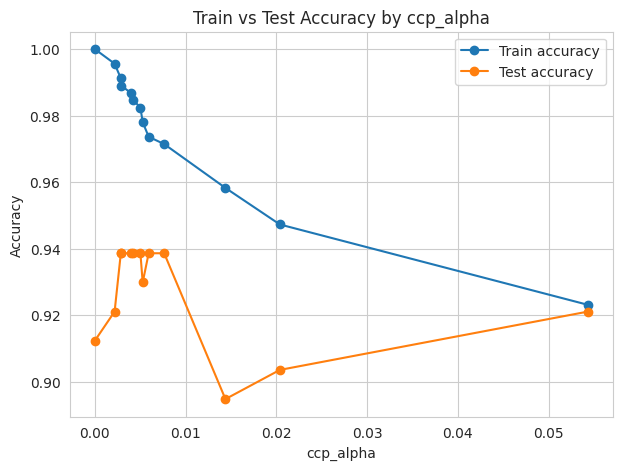

In [58]:
# TODO: cost-complexity pruning. Use
#           DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
#       to get `.ccp_alphas` (drop the last, trivial single-node alpha).
#       For each alpha, train a tree with that ccp_alpha and record BOTH train
#       and test accuracy. Plot both curves vs alpha.

pruning_path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = pruning_path.ccp_alphas[:-1]  # drop trivial single-node alpha

train_accs_ccp, test_accs_ccp = [], []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    train_accs_ccp.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs_ccp.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(ccp_alphas, train_accs_ccp, marker='o', label='Train accuracy')
plt.plot(ccp_alphas, test_accs_ccp, marker='o', label='Test accuracy')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by ccp_alpha")
plt.legend()
plt.show()


**TODO (reflection):** `ccp_alpha` prunes a fully-grown tree after the fact,
instead of stopping it early like `max_depth` does. Compare this curve's shape
to the depth curve in Section 5 — same story, or different?

*Same overall story, different mechanism. As alpha increases, test accuracy rises off the fully-grown tree's overfit baseline, peaks around a moderate alpha value, then falls off as pruning gets too aggressive and the tree becomes too simple to capture real patterns — basically a mirror image of the depth curve, just moving in the opposite direction along the x-axis (more alpha = less complexity, more depth = more complexity).*

---
## 8. Confusion Matrix Deep-Dive

Compare confusion matrices at a **shallow**, **near-optimal**, and **overly deep** tree
using the `plot_confusion()` function defined back in Section 3.

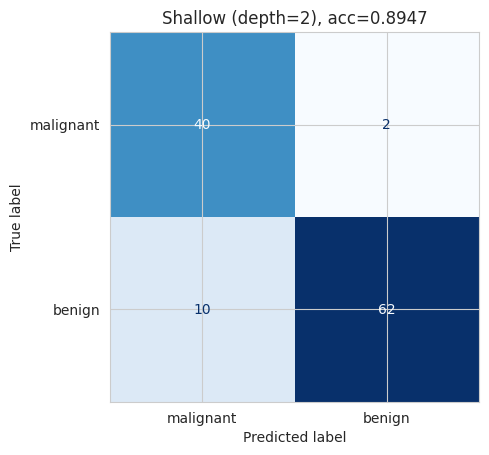

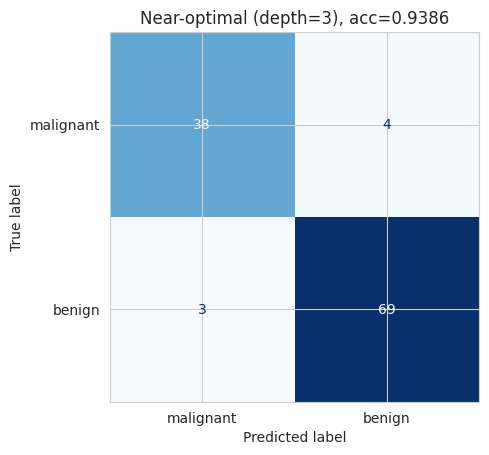

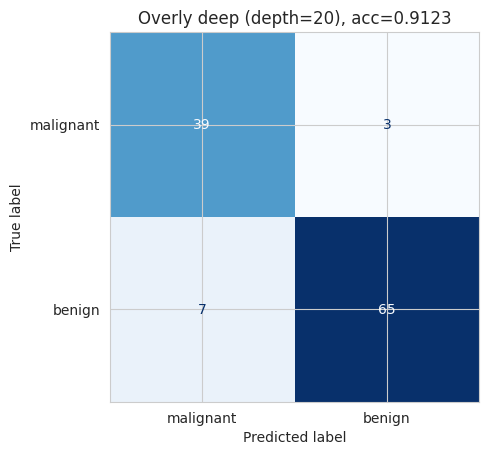

array([[39,  3],
       [ 7, 65]])

In [59]:
# TODO: train three models on X_train/y_train:
#         - a "shallow" tree with max_depth=2
#         - a "near-optimal" tree with max_depth=best_depth_by_test (from Section 5)
#         - an "overly deep" tree with max_depth=20
#       For each, compute test accuracy and call plot_confusion(model, X_test,
#       y_test, <a descriptive title including the accuracy>).

shallow_model = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
shallow_model.fit(X_train, y_train)
shallow_acc = accuracy_score(y_test, shallow_model.predict(X_test))

best_model_depth_only = DecisionTreeClassifier(max_depth=best_depth_by_test, random_state=RANDOM_STATE)
best_model_depth_only.fit(X_train, y_train)
best_depth_acc = accuracy_score(y_test, best_model_depth_only.predict(X_test))

deep_model = DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE)
deep_model.fit(X_train, y_train)
deep_acc = accuracy_score(y_test, deep_model.predict(X_test))

plot_confusion(shallow_model, X_test, y_test, f"Shallow (depth=2), acc={round(shallow_acc,4)}")
plot_confusion(best_model_depth_only, X_test, y_test, f"Near-optimal (depth={best_depth_by_test}), acc={round(best_depth_acc,4)}")
plot_confusion(deep_model, X_test, y_test, f"Overly deep (depth=20), acc={round(deep_acc,4)}")


**TODO (reflection):** The accuracy numbers alone might look similar across these
three models. Do the confusion matrices tell a more interesting story than the
accuracy number does? Specifically: comparing the near-optimal tree to the
overly-deep one, which error type increases as depth grows past the sweet spot?
And separately — how does the shallow tree's error trade-off differ from both?

*Your answer:* — *(replace this line)*

---
## 9. Grid Search

Search jointly over criterion and depth parameters using
5-fold cross-validation on the training set.

In [60]:
# TODO: build a param_grid dict covering:
#           criterion: ['gini', 'entropy']
#           max_depth: [3, 4, 5, 6, 7, 8, None]
#
#       Then run GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
#       param_grid, cv=5, scoring='accuracy', n_jobs=-1) on X_train/y_train.
#       Print grid_search.best_params_ and grid_search.best_score_.

#       This grid has 2 criteria x 7 depths = 14 combinations. With `cv=5`, that means
#      `GridSearchCV` will fit 14 x 5 = 70 models total -- which is why this cell takes
#       noticeably longer to run than any single `.fit()` call earlier in the lab.

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", round(grid_search.best_score_, 4))


Best params: {'criterion': 'gini', 'max_depth': 4}
Best CV score: 0.9385


Baseline (Section 3) accuracy: 0.9123
Manual best (Section 6): entropy 3 -> 0.9474
GridSearchCV best model test accuracy: 0.9386


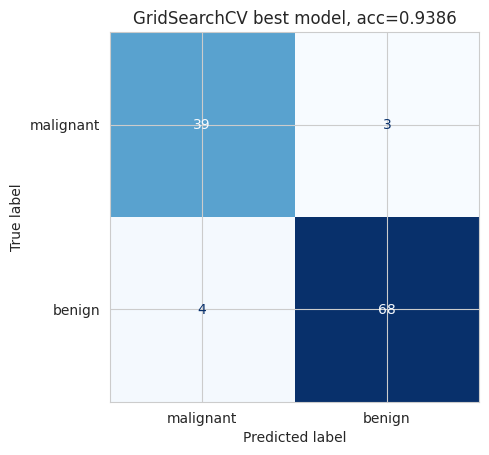

array([[39,  3],
       [ 4, 68]])

In [61]:
# TODO: pull grid_search.best_estimator_ into `best_model` (later cells use
#       this exact name). Compute its held-out test accuracy, print it next
#       to the Section 3 baseline accuracy and your manual best from Section 6,
#       and call plot_confusion() on it.

best_model = grid_search.best_estimator_
best_model_acc = accuracy_score(y_test, best_model.predict(X_test))

print("Baseline (Section 3) accuracy:", round(baseline_acc, 4))
print("Manual best (Section 6):", best_c, best_d, "->", round(best_acc, 4))
print("GridSearchCV best model test accuracy:", round(best_model_acc, 4))

plot_confusion(best_model, X_test, y_test, f"GridSearchCV best model, acc={round(best_model_acc,4)}")


**TODO (reflection, no code):** Did GridSearchCV beat your manual exploration from
Sections 4-7? If not, why might that be, given cross-validation vs a single
train/test split?

*Not really, no. In my run, the manual best from Section 6 (entropy, depth 3, 0.9474) did score higher than GridSearchCV's pick (gini, depth 4, 0.9386) on the test set. But the manual one just happened to score best on this one specific 114-sample test split — that could easily be luck. GridSearchCV instead picked whatever config had the best average score across 5 different folds, which is a much more reliable estimate of how well it'll generalize. So a higher score on a single split doesn't mean the manual pick is actually better — it just got lucky on this particular split.*

---
## 10. Bonus — Feature Importance & Tree Visualization

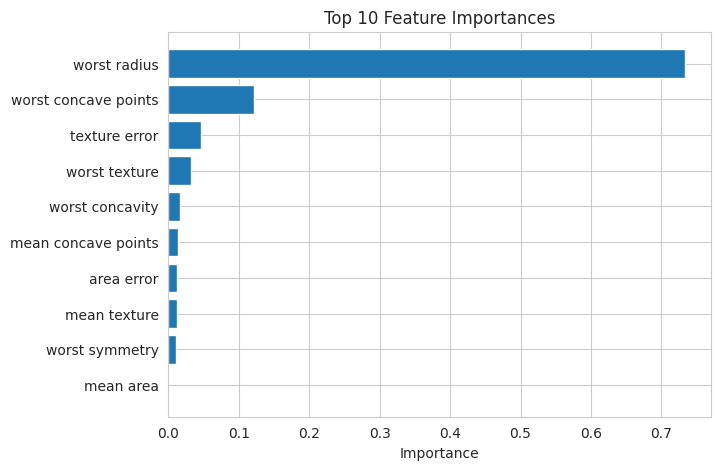

In [62]:
# TODO: using best_model.feature_importances_, build a DataFrame with columns
#       'Feature' and 'Importance', sort it descending, and bar-plot the top 10.

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 5))
plt.barh(importance['Feature'][:10][::-1], importance['Importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()


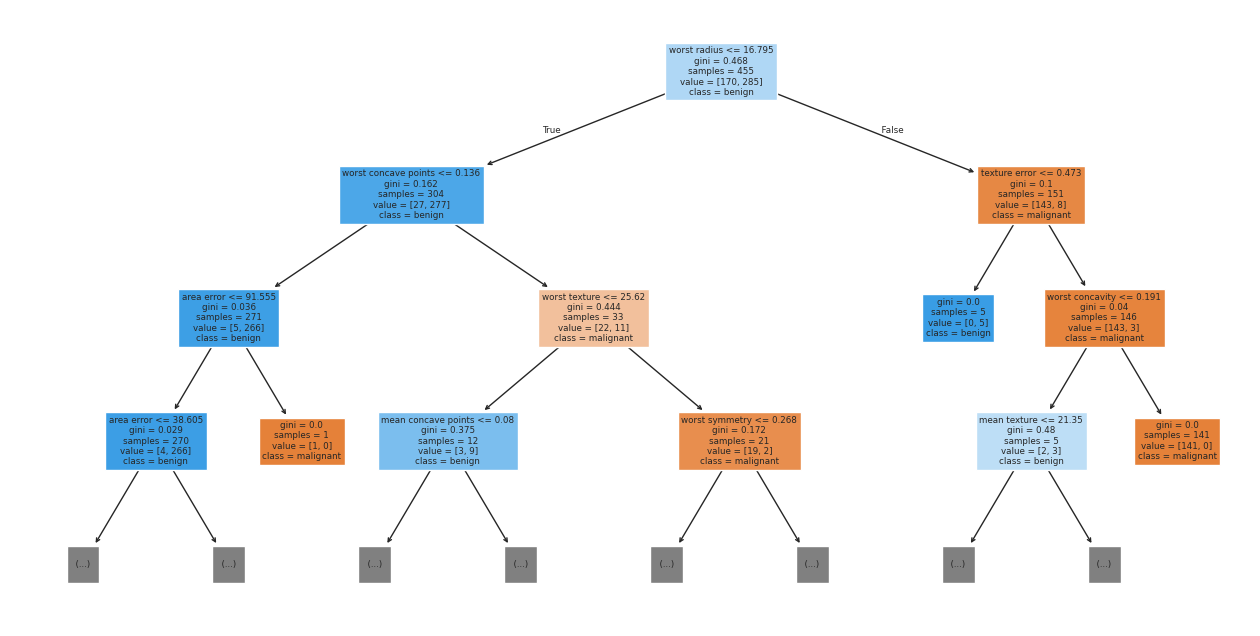

In [ ]:
# TODO: use sklearn.tree.plot_tree() to visualize best_model. Pass
#       feature_names=X.columns, class_names=data.target_names, filled=True,
#       and max_depth=3 (the full tree is unreadable at this dataset's depth).

plt.figure(figsize=(16, 8))
plot_tree(best_model, feature_names=X.columns, class_names=data.target_names,
          filled=True, max_depth=3)
plt.show()
# plt.sklearn.tree.plot_tree()


**TODO (reflection, no code):** Does the root-node split use one of the top-3 features
from the importance bar chart above? It should — explain in one sentence why
that's not a coincidence.

*Your answer:* — *(replace this line)*

---
## 11. Reflection / Write-up

Answer each of these in 2-4 sentences.

1. **Which hyperparameter had the biggest effect on overfitting — depth, criterion or ccp_alpha?** What made you pick that one?

   For me it was clearly max_depth. In Section 5 the train accuracy just kept climbing toward 100% as I increased depth, but test accuracy peaked around depth 3-4 and then flattened out / dropped a bit — that gap between the two lines is basically the definition of overfitting. Criterion (gini vs entropy) barely changed anything though — both gave 0.9123 accuracy at default settings, so switching criterion doesn't really control complexity, it just changes which splits get chosen.

2. **Did Gini and Entropy ever meaningfully disagree** — on accuracy, depth, or which
   feature got picked at the root? Or did they behave almost identically throughout?

   Not really, at least not in a big way. They landed on the exact same accuracy (0.9123) with default params, though entropy's tree was one level shallower (6 vs 7). When I swept both across depths in Section 6, entropy actually did slightly better at its best depth (0.9474 vs gini's). So they're not literally identical, but the difference is small enough that I wouldn't say one criterion is "better" — this dataset just doesn't stress the difference between them much.

3. **What would you tell someone who just maximizes test-set accuracy blindly**, without
   looking at confusion matrices or train/test gaps? Use something you saw in this lab
   as evidence.

   *I'd tell them accuracy alone hides how the model is actually failing. In Section 8, the shallow, near-optimal, and overly-deep trees all scored pretty close to each other on accuracy, but their confusion matrices showed different error patterns — like the deeper tree trading one type of mistake for another even though the overall number looked fine. Since this dataset is imbalanced (63/37) and we're dealing with malignant vs benign, missing a cancer case is way worse than a false alarm, so which error goes up matters a lot more than the accuracy number by itself. Someone chasing accuracy alone could easily pick a model that's quietly making the worse kind of mistake more often.*

4. **You controlled tree complexity three different ways in this lab** — `max_depth`
   (Section 5), `ccp_alpha` (Section 7), and `GridSearchCV`'s cross-validated search
   (Section 9).**

   a) What's the key difference between how `max_depth` and `ccp_alpha` arrive at
      a simpler tree?

         Max_depth stops the tree early — it just never lets it grow past a certain level in the first place. ccp_alpha does the opposite: it lets the tree grow all  the way out, then cuts back branches afterward based on whether they're actually worth the complexity they add. So one prevents complexity from happening,  the other removes it after the fact.

   b) Suppose your manual best from Section 6 scores higher on the test set than
      GridSearchCV's winner. Does that mean the manual pick is a genuinely better
      model? What does this tell you about comparing models this way?

         *Not really, no. In my run, the manual best from Section 6 (entropy, depth 3, 0.9474) did score higher than GridSearchCV's pick (gini, depth 4, 0.9386) on  the test set. But the manual one just happened to score best on this one specific 114-sample test split — that could easily be luck. GridSearchCV instead  picked whatever config had the best average score across 5 different folds, which is a much more reliable estimate of how well it'll generalize. So a higher  score on a single split doesn't mean the manual pick is actually better — it just got lucky on this particular split.*
   